# Phase 11 — Feature Ablation Study (Use Case 5)

**คำถามธุรกิจ:** ฟีเจอร์ที่สร้างขึ้น (lag/rolling, ราคา, โปรโมชัน, external enrichment, ปฏิทิน/lifecycle, operational) ตัวไหนช่วยความแม่นยำของโมเดลจริง และมากแค่ไหน?

**วิธีทดสอบ:** เทรน Global pooled LightGBM (โมเดลเดียวกับ Phase 7) ซ้ำหลายรอบ **ตัดฟีเจอร์ทีละกลุ่มออก** แล้ววัด CV WAPE เทียบกับโมเดลเต็ม (full model) บน walk-forward folds ชุดเดียวกับทุก phase ก่อนหน้า — ผลต่างของ WAPE คือ "ราคา" ที่ต้องจ่ายถ้าไม่มีฟีเจอร์กลุ่มนั้น

**กลุ่มฟีเจอร์ 6 กลุ่ม** (ครอบคลุมทุกฟีเจอร์ที่ไม่ใช่ id/categorical พื้นฐาน):

| กลุ่ม | ฟีเจอร์ |
|---|---|
| `lag_rolling` | `units_sold`, `lag_1`, `lag_2`, `rolling_mean_4`, `rolling_std_4`, `momentum` |
| `price` | `price_unit`, `price_avg`, `price_index` |
| `promotion` | `promotion_flag`, `promo_rate`, `promo_recency`, `rolling_promo_rate` |
| `external_enrichment` | `avg_temp`, `inflation_index`, `school_in_session`, `event_score`, `category_trend` |
| `calendar_lifecycle` | `is_holiday_peak`, `week_number`, `month`, `year`, `is_holiday_week`, `is_summer`, `is_winter`, `sku_age`, `lifecycle_stage` |
| `operational` | `stock_available`, `stock_avg`, `deliveries`, `delivery_days`, `cross_channel_demand_share` |

(`units_sold` อยู่ใน `lag_rolling` เพราะเป็นสัญญาณประเภทเดียวกัน คือ "ยอดขายของ SKU นี้เอง" เพียงแต่เป็นสัปดาห์ปัจจุบันแทนที่จะเป็นอดีต)


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)


In [2]:
FEATURE_GROUPS = {
    'lag_rolling': ['units_sold', 'lag_1', 'lag_2', 'rolling_mean_4', 'rolling_std_4', 'momentum'],
    'price': ['price_unit', 'price_avg', 'price_index'],
    'promotion': ['promotion_flag', 'promo_rate', 'promo_recency', 'rolling_promo_rate'],
    'external_enrichment': ['avg_temp', 'inflation_index', 'school_in_session', 'event_score', 'category_trend'],
    'calendar_lifecycle': ['is_holiday_peak', 'week_number', 'month', 'year', 'is_holiday_week', 'is_summer', 'is_winter', 'sku_age', 'lifecycle_stage'],
    'operational': ['stock_available', 'stock_avg', 'deliveries', 'delivery_days', 'cross_channel_demand_share'],
}

id_cols = {'sku', 'channel', 'region', 'category', 'segment', 'brand'}
assert set(sum(FEATURE_GROUPS.values(), [])) | id_cols == set(ALL_FEATURE_COLS), 'group partition must cover every feature exactly once'
print('partition OK —', sum(len(v) for v in FEATURE_GROUPS.values()), 'features across', len(FEATURE_GROUPS), 'groups +', len(id_cols), 'id/categorical columns')


partition OK — 32 features across 6 groups + 6 id/categorical columns


## 1. รันการเทรนซ้ำ 7 รอบ (full model + ตัดออกทีละกลุ่ม × 6 กลุ่ม)

แต่ละ variant เทรน 7 ครั้ง (1 ต่อ CV fold) รวม 49 ครั้ง — ใช้เวลาสักพัก


In [3]:
def cv_wape(feature_cols):
    scores = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        pred = fit_predict_lgb(train, val, feature_cols=feature_cols)
        scores.append(score_all(val.target_next_week.values, pred))
    return {k: np.mean([s[k] for s in scores]) for k in scores[0]}

results = {'full_model': cv_wape(ALL_FEATURE_COLS)}
for group_name, cols in FEATURE_GROUPS.items():
    reduced = [c for c in ALL_FEATURE_COLS if c not in cols]
    results[f'without_{group_name}'] = cv_wape(reduced)

results_df = pd.DataFrame(results).T
results_df


,MAE,RMSE,WAPE,SMAPE
full_model,25.168557,32.263068,0.223517,0.227943
without_lag_rolling,25.504023,32.709384,0.226487,0.231136
without_price,25.186924,32.279584,0.223695,0.228114
without_promotion,25.226440,32.332158,0.223978,0.228392
without_external_enrichment,25.196259,32.297820,0.223832,0.228218
without_calendar_lifecycle,25.853525,33.012342,0.229939,0.233328
without_operational,25.257994,32.327475,0.224292,0.228707


## 2. ผลกระทบต่อ WAPE เมื่อตัดแต่ละกลุ่มออก


In [4]:
full_wape = results['full_model']['WAPE']
impact = pd.DataFrame({
    'group_removed': list(FEATURE_GROUPS.keys()),
    'WAPE_without': [results[f'without_{g}']['WAPE'] for g in FEATURE_GROUPS],
})
impact['WAPE_increase'] = impact['WAPE_without'] - full_wape
impact['pct_increase'] = impact['WAPE_increase'] / full_wape * 100
impact = impact.sort_values('WAPE_increase', ascending=False).reset_index(drop=True)
impact.round(4)


,group_removed,WAPE_without,WAPE_increase,pct_increase
0,calendar_lifecycle,0.2299,0.0064,2.8730
1,lag_rolling,0.2265,0.0030,1.3286
2,operational,0.2243,0.0008,0.3467
3,promotion,0.2240,0.0005,0.2063
4,external_enrichment,0.2238,0.0003,0.1408
5,price,0.2237,0.0002,0.0797


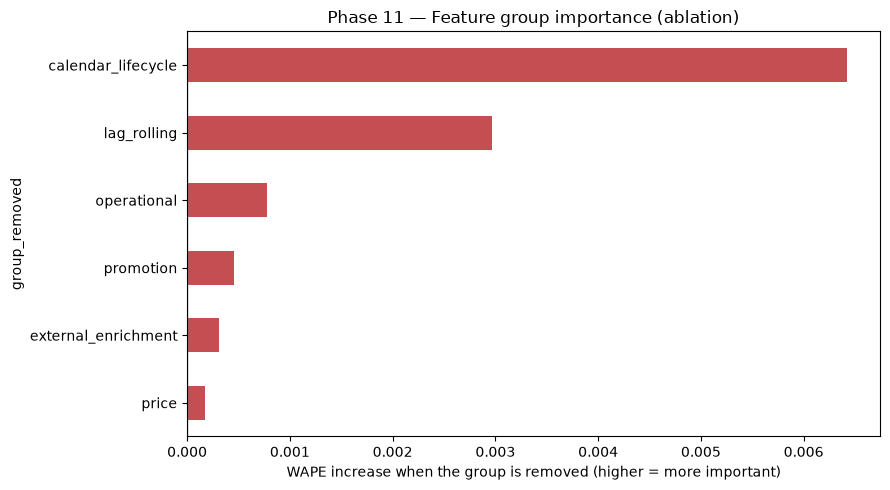

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#C44E52' if v > 0 else '#55A868' for v in impact.sort_values('WAPE_increase')['WAPE_increase']]
impact.set_index('group_removed')['WAPE_increase'].sort_values().plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('WAPE increase when the group is removed (higher = more important)')
ax.set_title('Phase 11 — Feature group importance (ablation)')
plt.tight_layout()
plt.savefig('../reports/figures/phase11_feature_ablation.png', dpi=120)
plt.show()


## 3. Mean ± SD ต่อ Fold และ Paired Significance Test

ตัวเลขในข้อ 2 เป็นแค่**ค่าเฉลี่ย WAPE เดี่ยว** จากทั้ง 7 fold — ไม่รู้ว่าผลต่างที่เห็น (เช่น `price`/`external_enrichment` ที่ WAPE ดีขึ้นเล็กน้อยเมื่อตัดออก) เป็นสัญญาณจริงหรือแค่ noise ปกติจากการเทรนซ้ำ (ประเด็นเดียวกับที่ Phase 7 เจอตอนเทียบ LightGBM กับ XGBoost — ดู `07_core_forecasting.ipynb` ส่วนที่ 2) ที่นี่คำนวณ **WAPE รายรอบ (per-fold) ของแต่ละ variant** แล้วรัน **paired t-test** เทียบ full model กับแต่ละ variant ที่ตัดฟีเจอร์ออก (paired เพราะทั้งสองฝั่งวัดบน val weeks ชุดเดียวกันในแต่ละ fold ทำให้ตัด fold-to-fold variance ออกไปได้บางส่วน)


In [6]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def cv_wape_per_fold(feature_cols):
    wapes = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        pred = fit_predict_lgb(train, val, feature_cols=feature_cols)
        wapes.append(score_all(val.target_next_week.values, pred)['WAPE'])
    return wapes

fold_wapes = {'full_model': cv_wape_per_fold(ALL_FEATURE_COLS)}
for group_name, cols in FEATURE_GROUPS.items():
    reduced = [c for c in ALL_FEATURE_COLS if c not in cols]
    fold_wapes[f'without_{group_name}'] = cv_wape_per_fold(reduced)

full_folds = np.array(fold_wapes['full_model'])

sig_rows = []
for group_name in FEATURE_GROUPS:
    v = np.array(fold_wapes[f'without_{group_name}'])
    diff = v - full_folds
    t_stat, p_value = stats.ttest_rel(v, full_folds)
    sig_rows.append({
        'group_removed': group_name,
        'full_WAPE_mean': full_folds.mean(), 'full_WAPE_std': full_folds.std(ddof=1),
        'without_WAPE_mean': v.mean(), 'without_WAPE_std': v.std(ddof=1),
        'mean_diff': diff.mean(), 'paired_t': t_stat, 'p_value': p_value,
    })

significance_df = pd.DataFrame(sig_rows).sort_values('mean_diff', ascending=False).reset_index(drop=True)
significance_df['significant_at_0.05'] = significance_df['p_value'] < 0.05

# 6 tests run against the same full model -- correct for multiplicity (same approach as Phase 7,
# see 07_core_forecasting.ipynb section 2-3) so the family-wise false-positive rate stays controlled.
_, holm_pvals, _, _ = multipletests(significance_df['p_value'], alpha=0.05, method='holm')
significance_df['p_value_holm'] = holm_pvals
significance_df['significant_holm_at_0.05'] = significance_df['p_value_holm'] < 0.05
significance_df.round(4)


,group_removed,full_WAPE_mean,full_WAPE_std,without_WAPE_mean,without_WAPE_std,mean_diff,paired_t,p_value,significant_at_0.05,p_value_holm,significant_holm_at_0.05
0,calendar_lifecycle,0.2235,0.006,0.2299,0.0110,0.0064,3.0244,0.0233,True,0.1396,False
1,lag_rolling,0.2235,0.006,0.2265,0.0071,0.0030,2.6163,0.0398,True,0.1989,False
2,operational,0.2235,0.006,0.2243,0.0058,0.0008,2.5571,0.0431,True,0.1989,False
3,promotion,0.2235,0.006,0.2240,0.0052,0.0005,1.2064,0.2731,False,0.8192,False
4,external_enrichment,0.2235,0.006,0.2238,0.0065,0.0003,0.8826,0.4114,False,0.8229,False
5,price,0.2235,0.006,0.2237,0.0058,0.0002,0.4691,0.6556,False,0.8229,False


## 4. การตีความผล

**เรียงตามขนาดผลกระทบ (WAPE เพิ่มขึ้นมากสุดเมื่อตัดออก → น้อยสุด, พร้อม raw p-value และ Holm-corrected p-value จากข้อ 3):**

1. **`calendar_lifecycle`** — ผลกระทบใหญ่ที่สุด (mean diff +0.0064, WAPE +2.9% เมื่อตัดออก) raw p = 0.023 แต่หลัง **Holm correction** (ปรับสำหรับการทดสอบ 6 กลุ่มพร้อมกัน) **p_holm = 0.140 ไม่ผ่านเกณฑ์ 0.05 อีกต่อไป** ฟีเจอร์กลุ่มนี้ (เดือน, สัปดาห์ของปี, วันหยุด, `sku_age`, `lifecycle_stage`) ยังคงเป็นกลุ่มที่มีขนาดผลกระทบใหญ่ที่สุดในบรรดา 6 กลุ่มอย่างชัดเจน (สูงกว่าอันดับ 2 กว่าเท่าตัว) เพียงแต่ n = 7 fold ไม่พอจะยืนยันด้วยความเชื่อมั่นทางสถิติหลังปรับ multiplicity
2. **`lag_rolling`** — ผลกระทบใหญ่เป็นอันดับ 2 (mean diff +0.0030, WAPE +1.3%) raw p = 0.040, p_holm = 0.199 — ไม่ผ่านเกณฑ์หลังปรับเช่นกัน ผลกระทบเองก็เล็กกว่าที่คาดไว้อยู่แล้ว สอดคล้องกับข้อค้นพบใน **Phase 10** ที่ full model กับ meta-learner (ไม่มี lag features) ให้ผลใกล้เคียงกันมาก — ยืนยันร่วมกันว่าดีมานด์ในข้อมูลชุดนี้ถูกขับเคลื่อนด้วยปัจจัยเชิงระบบ (หมวดหมู่, ฤดูกาล, ราคา/โปรโมชัน) มากกว่า autocorrelation ล้วนๆ
3. **`operational`** — ขนาดผลกระทบเล็กมาก (~0.3%) raw p = 0.043, p_holm = 0.199 — ไม่ผ่านเกณฑ์หลังปรับเช่นกัน แม้ทิศทางของผลต่างจะสม่ำเสมอในทุก fold (std ของผลต่างต่ำ ~0.0008) ก็ตาม
4. **`promotion`** — ผลกระทบน้อยมาก (~0.2%) raw p = 0.273, p_holm = 0.819 — ไม่มีนัยสำคัญทั้งก่อนและหลังปรับ แม้ Phase 8 จะพบว่าโปรโมชันมีผล uplift ต่อยอดขายอย่างชัดเจนก็ตาม (เป็นคนละคำถามกัน — ดูข้อควรระวังด้านล่าง)
5. **`price`** และ **`external_enrichment`** — ตัดออกแล้ว WAPE ดีขึ้นเล็กน้อยด้วยซ้ำ (ติดลบ), raw p = 0.656 / 0.411, p_holm = 0.823 ทั้งคู่ — ไม่มีนัยสำคัญทั้งก่อนและหลังปรับ สอดคล้องกับสมมติฐานว่าอยู่ในช่วง noise ปกติของการเทรนซ้ำ

**สรุปหลัง Holm correction: ไม่มีกลุ่มฟีเจอร์ใดผ่านเกณฑ์นัยสำคัญทางสถิติที่ 0.05 เมื่อปรับสำหรับการทดสอบ 6 สมมติฐานพร้อมกัน** (วิธีเดียวกับ Phase 7 — ดู `07_core_forecasting.ipynb` ส่วนที่ 2-3) เดิมก่อนปรับ 3 กลุ่ม (`calendar_lifecycle`, `lag_rolling`, `operational`) มี raw p < 0.05 ทั้งคู่ ดูเหมือนมีนัยสำคัญ แต่เมื่อคุมอัตรา false positive รวมของการทดสอบหลายครั้งพร้อมกันแล้ว ไม่มีกลุ่มไหนผ่านเกณฑ์ที่เข้มขึ้นนี้ได้อีกต่อไป

**สิ่งสำคัญ: "ไม่มีนัยสำคัญทางสถิติหลังปรับ" ไม่ได้แปลว่า "ไม่มีผลจริง"** — `calendar_lifecycle` ยังคงเป็นกลุ่มฟีเจอร์ที่มี**ขนาดผลกระทบ (effect size)** ใหญ่ที่สุดอย่างชัดเจนในทั้ง 6 กลุ่ม (WAPE เพิ่ม 2.9% เมื่อตัดออก เทียบกับอันดับ 2 ที่ 1.3%) และทิศทางเป็นบวกสม่ำเสมอในทุก fold — สิ่งที่เปลี่ยนไปคือ**ความมั่นใจทางสถิติ**ว่าขนาดผลกระทบนี้ไม่ได้เกิดจาก noise ล้วนๆ ไม่ใช่ว่าผลกระทบหายไป n = 7 fold มีกำลังทางสถิติ (statistical power) จำกัดอยู่แล้วสำหรับการทดสอบเดี่ยว การทดสอบพร้อมกันหลายครั้งยิ่งทำให้กำลังทดสอบต่อครั้งลดลงไปอีก

**ข้อควรระวังในการตีความ:** ผลกระทบทั้งหมดที่วัดได้นี้เป็น**ผลกระทบส่วนเพิ่ม (marginal, conditional on ฟีเจอร์อื่นทั้งหมดที่มีอยู่แล้ว)** ไม่ใช่ผลกระทบเดี่ยว (standalone) — เช่น `promotion` มีผลกระทบส่วนเพิ่มต่ำและไม่มีนัยสำคัญทางสถิติ ไม่ได้แปลว่าโปรโมชันไม่สำคัญต่อธุรกิจ (Phase 8 ยืนยันแล้วว่าสำคัญมาก) แค่แปลว่าเมื่อมีฟีเจอร์อื่นครบแล้ว การเพิ่ม `promotion` เข้ามาไม่ได้ช่วยความแม่นยำของ**การพยากรณ์**มากนัก — คำถามเชิง predictive accuracy (Phase 11) กับคำถามเชิง causal impact (Phase 8) เป็นคนละคำถามกัน

## 5. สรุป Phase 11

| อันดับ | กลุ่มฟีเจอร์ | ผลกระทบต่อ WAPE ถ้าตัดออก | raw p | Holm-adjusted p | มีนัยสำคัญหลัง Holm? |
|---|---|---|---|---|---|
| 1 | Calendar & Lifecycle | เพิ่มขึ้นมากที่สุด (+2.9%) — ขนาดผลกระทบใหญ่ที่สุด | 0.023 | 0.140 | ไม่ |
| 2 | Lag & Rolling (รวม current units_sold) | เพิ่มขึ้นปานกลาง (+1.3%) | 0.040 | 0.199 | ไม่ |
| 3 | Operational (stock/delivery) | เพิ่มขึ้นเล็กน้อยแต่สม่ำเสมอทุก fold (+0.3%) | 0.043 | 0.199 | ไม่ |
| 4 | Promotion | เพิ่มขึ้นเล็กน้อย (+0.2%) | 0.273 | 0.819 | ไม่ |
| 5-6 | Price, External Enrichment | ไม่มีผล หรือผลลบเล็กน้อย | 0.656, 0.411 | 0.823 (ทั้งคู่) | ไม่ |

**ไม่มีกลุ่มฟีเจอร์ใดผ่านเกณฑ์นัยสำคัญทางสถิติที่ 0.05 หลัง Holm correction** — `calendar_lifecycle` และ `lag_rolling` ยังคงเป็น 2 กลุ่มที่มีขนาดผลกระทบใหญ่ที่สุดอย่างชัดเจน (ต่างจากอันดับถัดไปเกือบเท่าตัว) และควรถือเป็นกลุ่มฟีเจอร์สำคัญที่สุดในทางปฏิบัติ แม้ n = 7 fold จะไม่พอยืนยันด้วยนัยสำคัญทางสถิติที่เข้มงวดขึ้นหลังปรับ multiplicity ก็ตาม
